In [29]:
#import libraries
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# PCA
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

In [30]:
#load data set
df = pd.read_csv("C:\\Users\\gagan\\Downloads\\wine.csv")

df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [31]:
#basic data exploration
print("Shape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Shape of dataset:
(178, 14)

Columns:
Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    f

In [32]:
#check duplicate values
print("Duplicate rows =",df.duplicated().sum())

Duplicate rows = 0


In [5]:
df=df.drop_duplicates()

In [33]:
#seperate features and target
X=df.drop("Type",axis=1)

y=df["Type"]

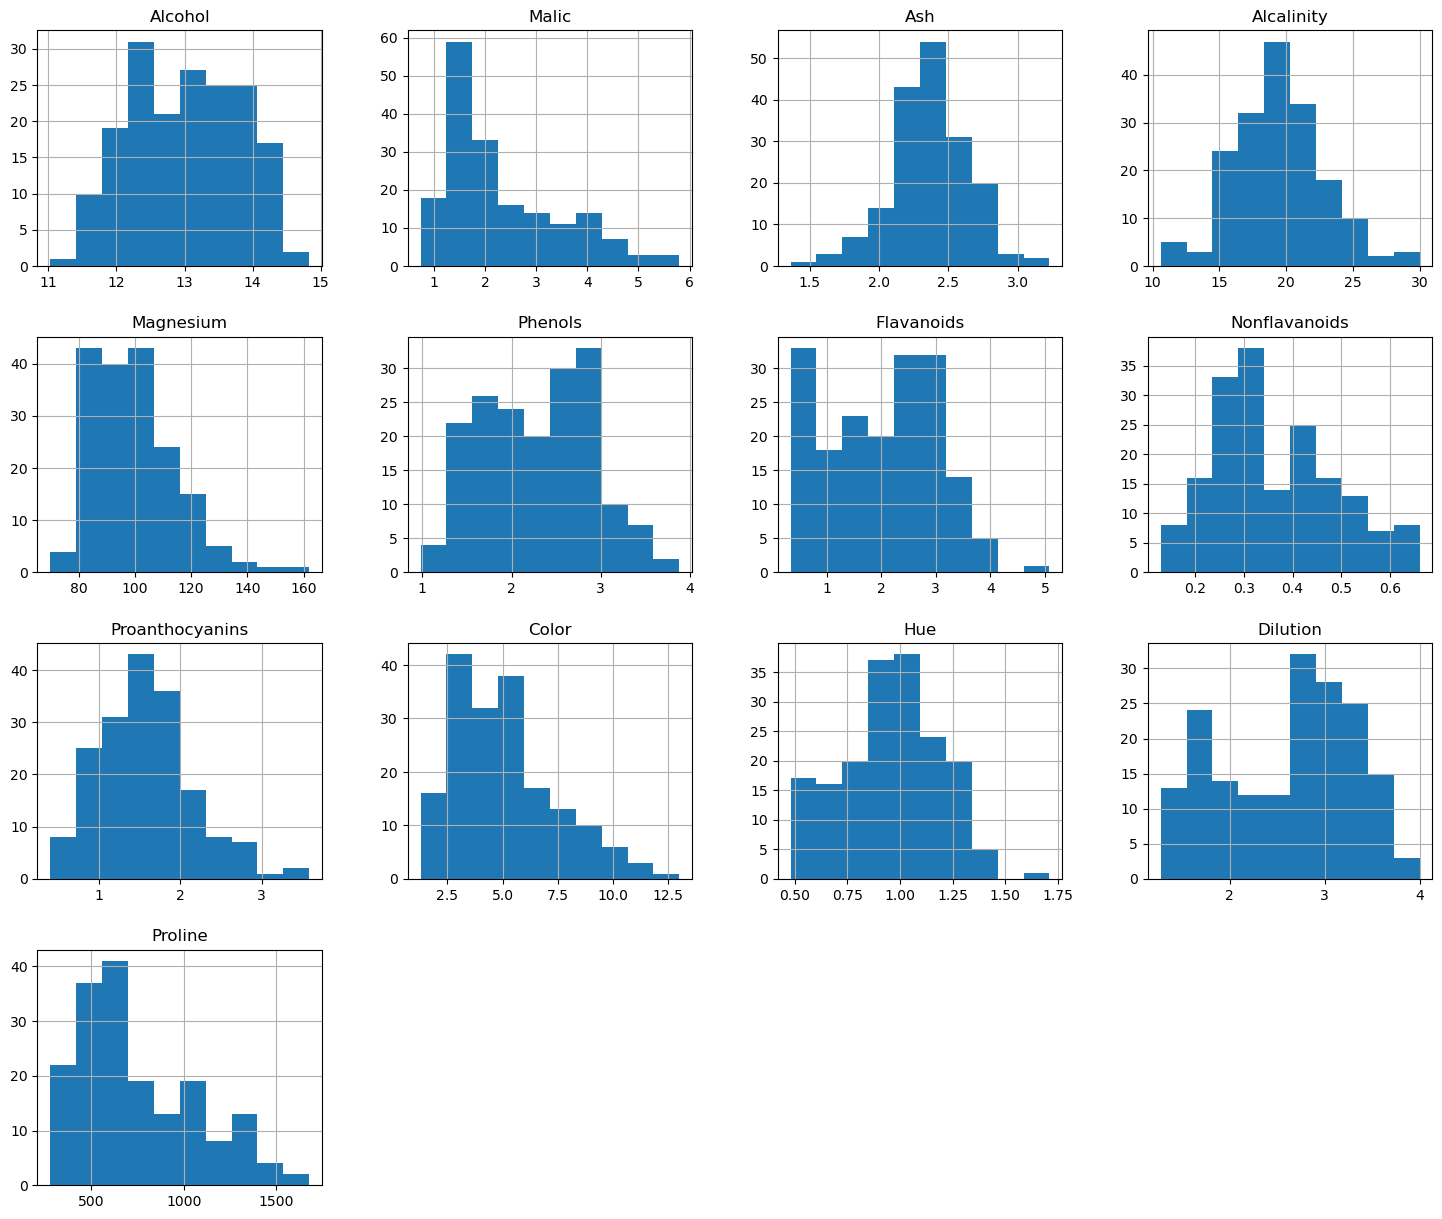

In [34]:
#histograms
X.hist(figsize=(18,15))

plt.show()

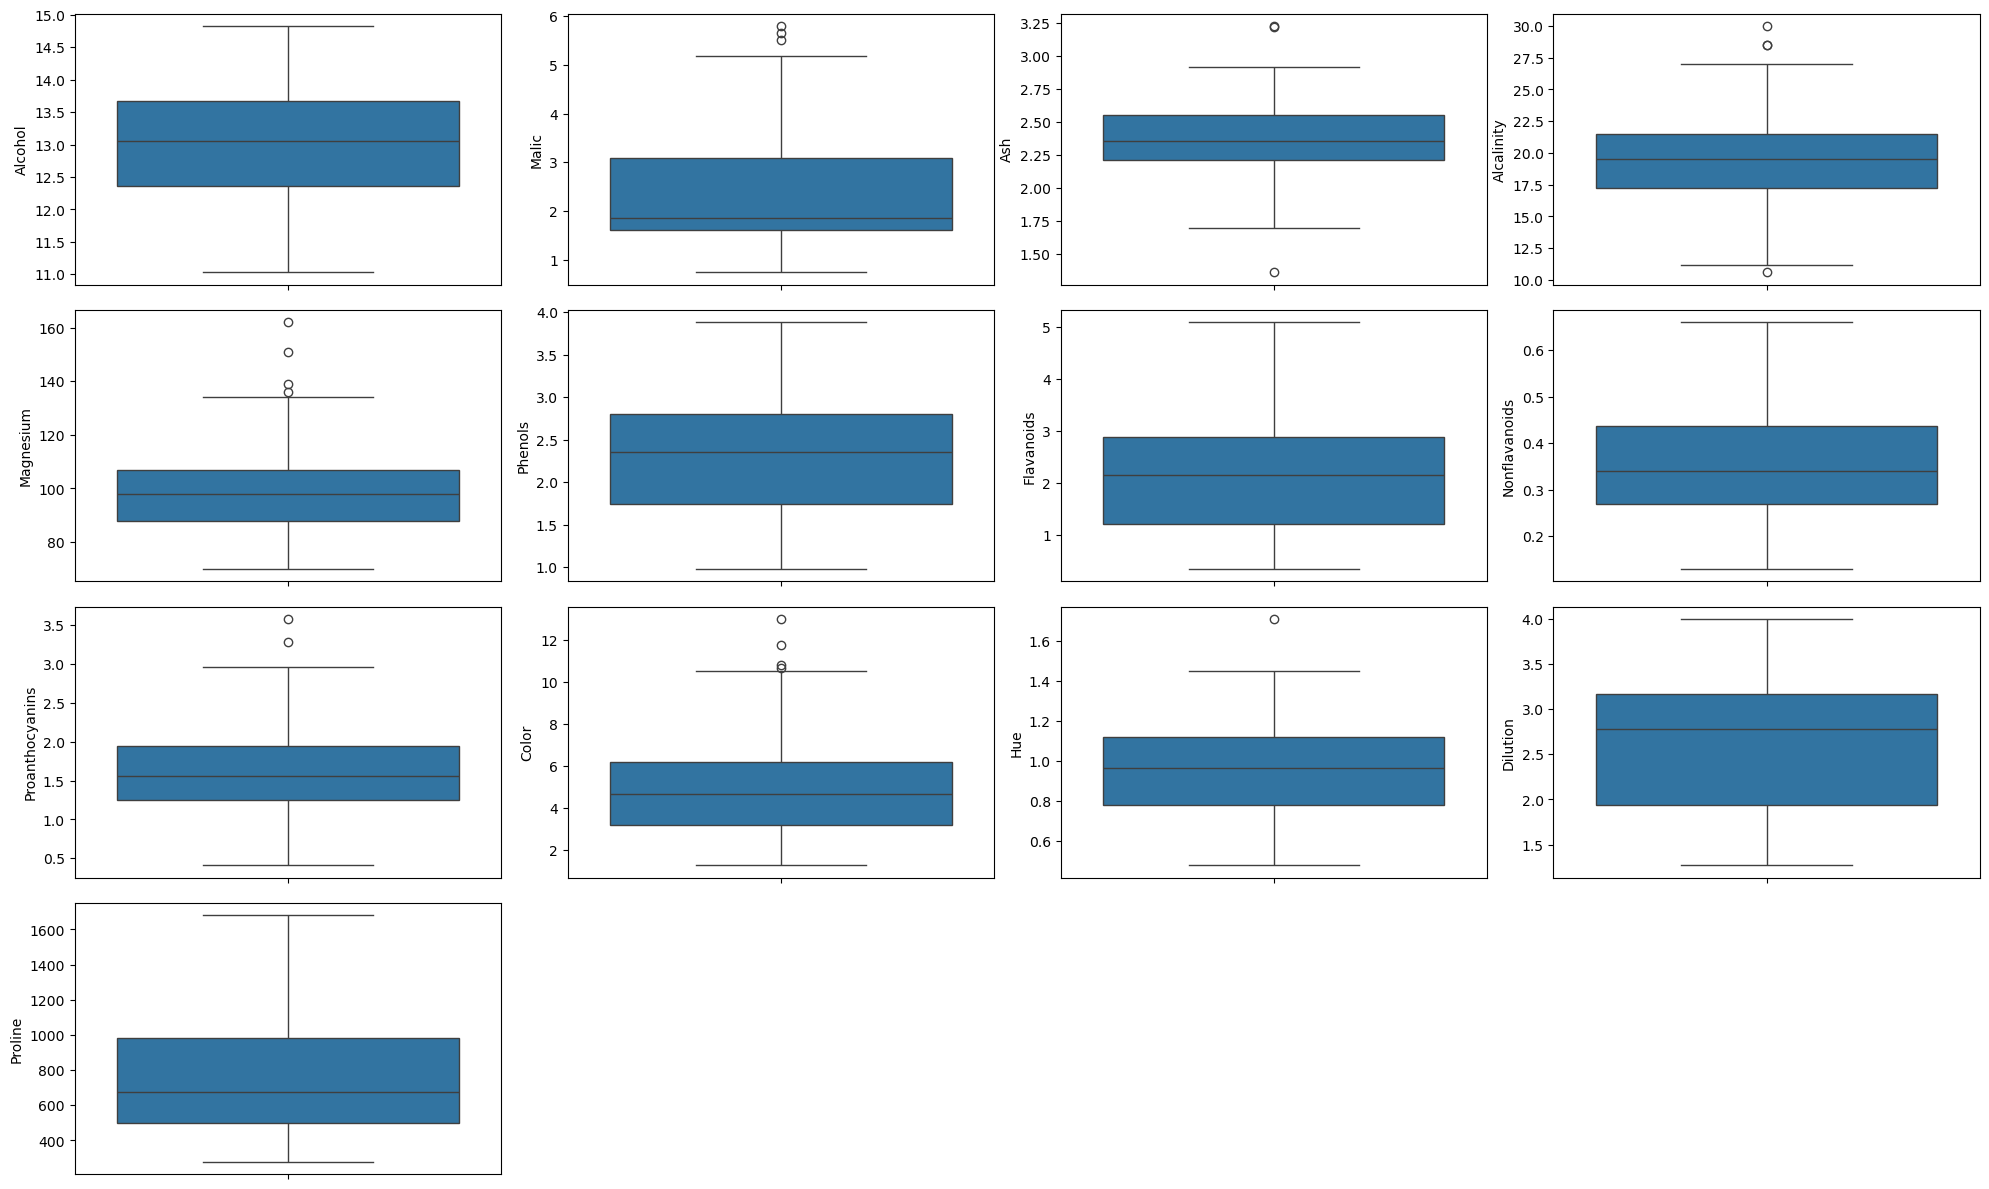

In [35]:
#boxplot for outliers
plt.figure(figsize=(20,12))

for i,col in enumerate(X.columns):
    
    plt.subplot(4,4,i+1)
    
    sns.boxplot(X[col])

plt.tight_layout()

plt.show()

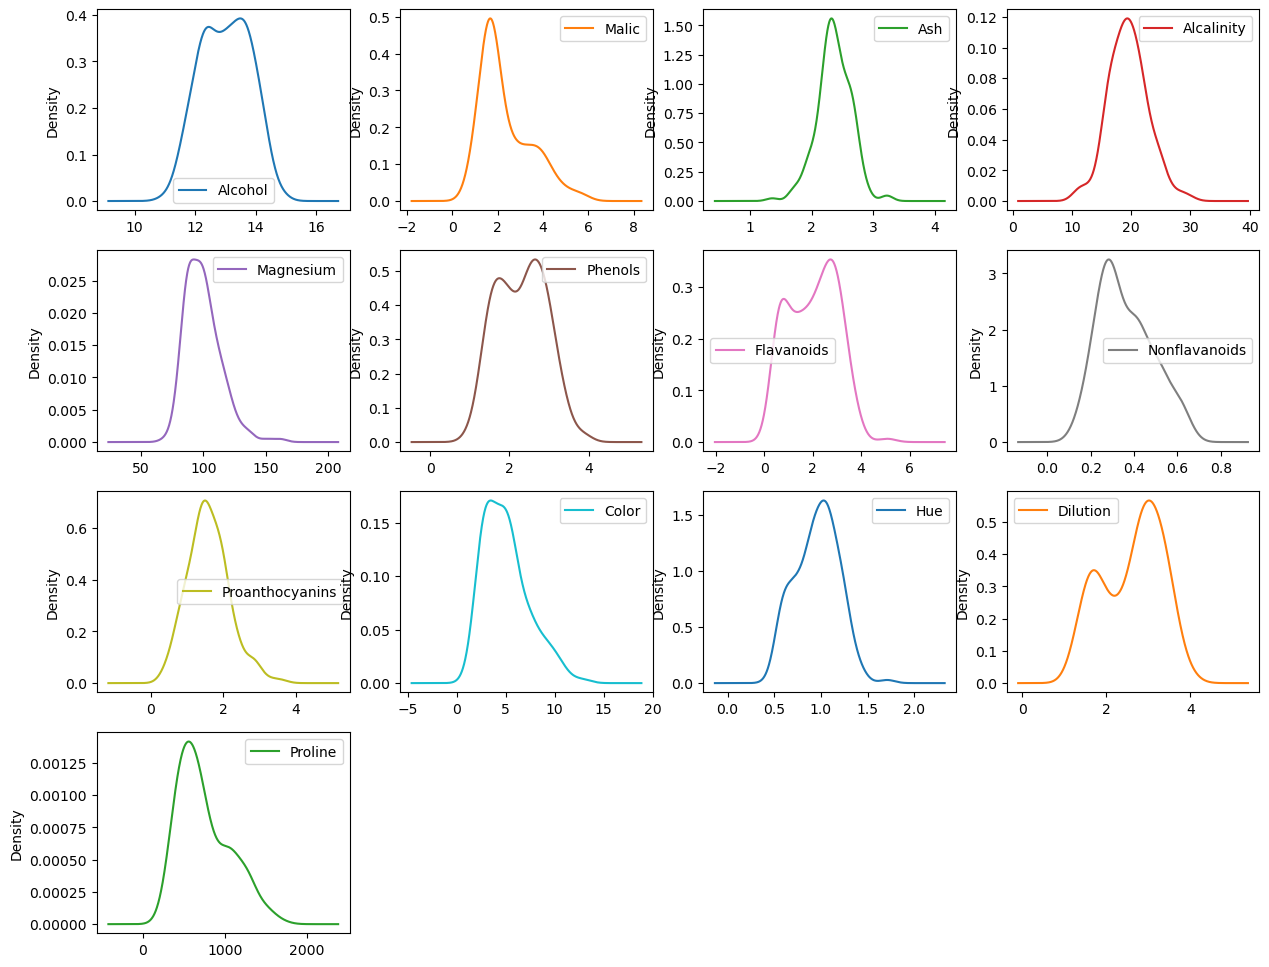

In [10]:
#density plot
X.plot(kind='density',
       subplots=True,
       layout=(4,4),
       figsize=(15,12),
       sharex=False)

plt.show()

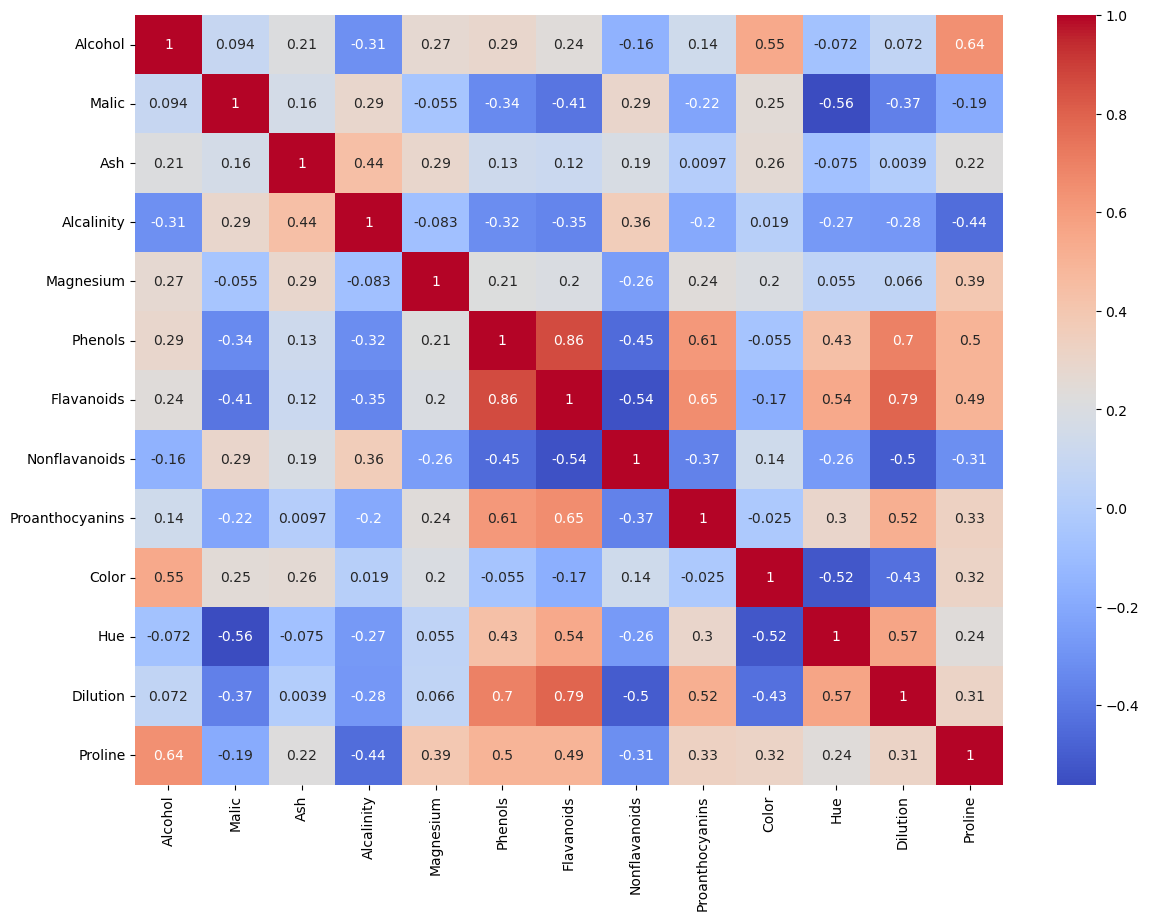

In [11]:
#correlation analysis
plt.figure(figsize=(14,10))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [12]:
#standardization
scaler=StandardScaler()

scaled=scaler.fit_transform(X)

scaled=pd.DataFrame(
    scaled,
    columns=X.columns
)

scaled.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [13]:
#apply pca
pca=PCA()

pca_data=pca.fit_transform(scaled)

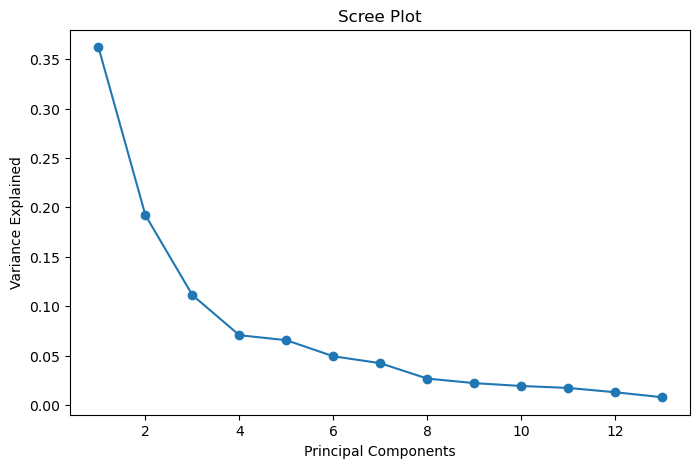

In [14]:
#scree plot
explained=pca.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(explained)+1),
    explained,
    marker='o'
)

plt.xlabel("Principal Components")

plt.ylabel("Variance Explained")

plt.title("Scree Plot")

plt.show()

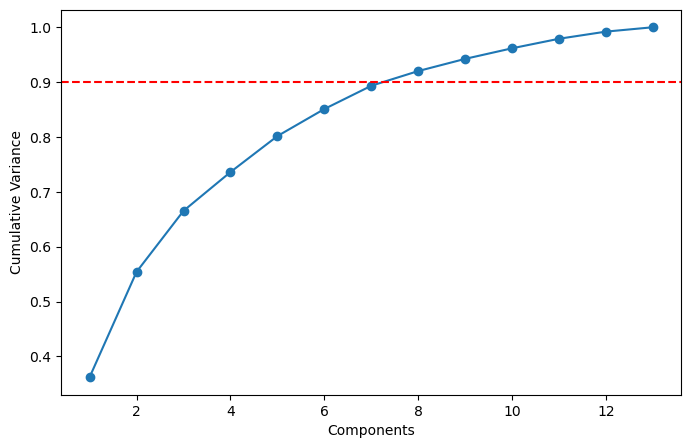

In [15]:
#cumulative explained varience
cum=np.cumsum(explained)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(cum)+1),
    cum,
    marker='o'
)

plt.axhline(
    y=.90,
    color='r',
    linestyle='--'
)

plt.xlabel("Components")

plt.ylabel("Cumulative Variance")

plt.show()

In [16]:
#choose components
pca=PCA(n_components=2)

pca_data=pca.fit_transform(scaled)

pca_df=pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)

pca_df.head()

,PC1,PC2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


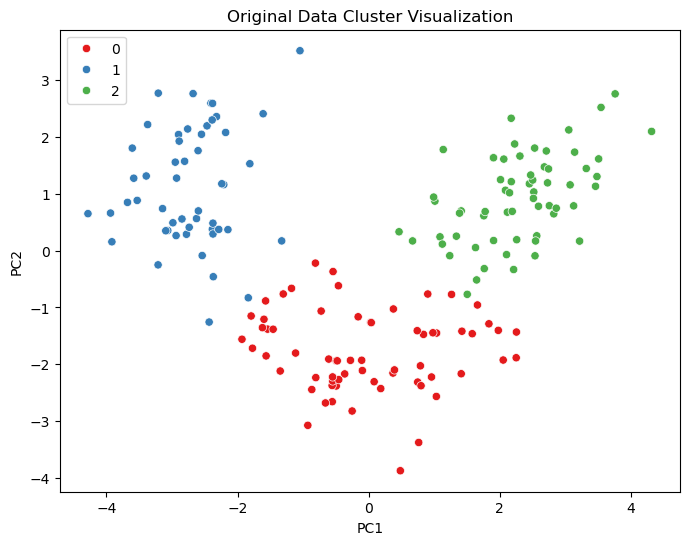

In [36]:
temp=PCA(n_components=2)

vis=temp.fit_transform(scaled)

vis=pd.DataFrame(vis,
                 columns=['PC1','PC2'])

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue=cluster_original,
    data=vis,
    palette='Set1'
)

plt.title(
    "Original Data Cluster Visualization"
)

plt.show()

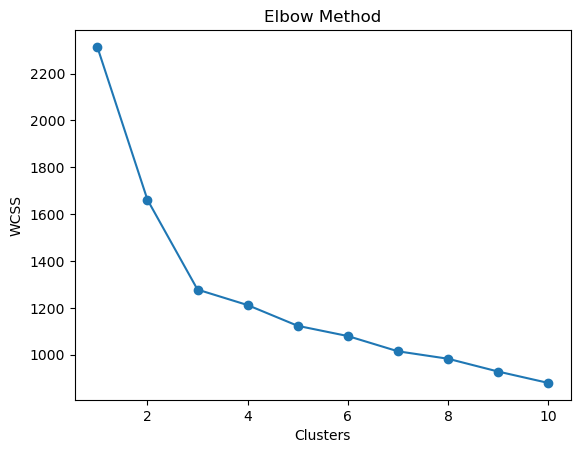

In [20]:
#elbow plot
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [22]:
#train k-means
kmeans=KMeans(
    n_clusters=3,
    random_state=42
)

cluster_original=kmeans.fit_predict(scaled)

In [23]:
#evaluate original data
sil=silhouette_score(
    scaled,
    cluster_original
)

db=davies_bouldin_score(
    scaled,
    cluster_original
)

print("Silhouette Score:",sil)

print("Davies Bouldin:",db)

Silhouette Score: 0.2848589191898987
Davies Bouldin: 1.389187977718165


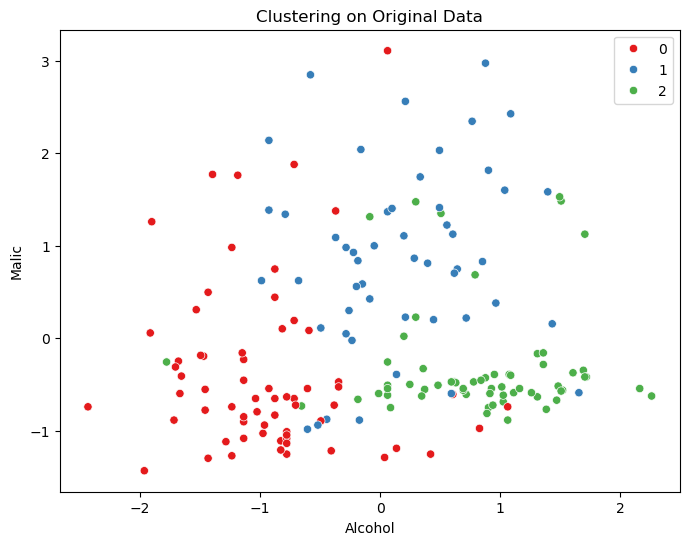

In [24]:
#visualization original clustering
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=scaled.iloc[:,0],
    y=scaled.iloc[:,1],
    hue=cluster_original,
    palette='Set1'
)

plt.title(
    "Clustering on Original Data"
)

plt.show()

In [25]:
#kmeans on pca data
kmeans2=KMeans(
    n_clusters=3,
    random_state=42
)

cluster_pca=kmeans2.fit_predict(pca_df)

In [26]:
#pca cluster evaluation
sil2=silhouette_score(
    pca_df,
    cluster_pca
)

db2=davies_bouldin_score(
    pca_df,
    cluster_pca
)

print("PCA Silhouette:",sil2)

print("PCA Davies:",db2)

PCA Silhouette: 0.5601697480957203
PCA Davies: 0.5977226208167411


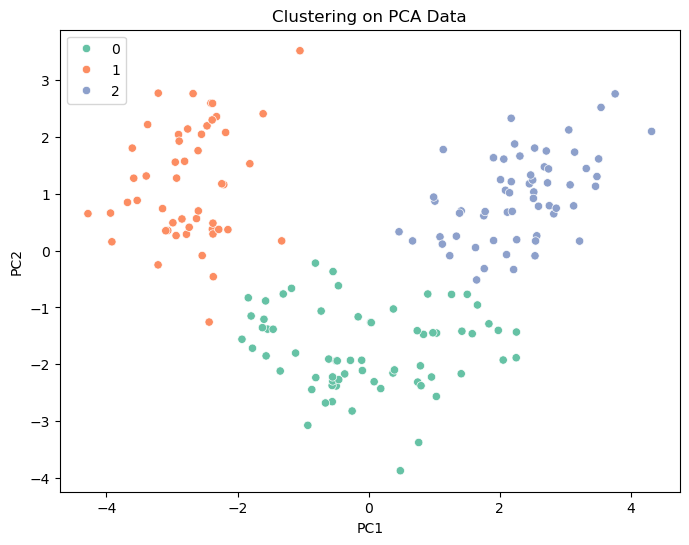

In [27]:
#visualize pca clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue=cluster_pca,
    data=pca_df,
    palette='Set2'
)

plt.title(
    "Clustering on PCA Data"
)

plt.show()

In [37]:
#compare result
result=pd.DataFrame({

'Method':['Original','PCA'],

'Silhouette':
[sil,sil2],

'Davies':
[db,db2]

})

print(result)

     Method  Silhouette    Davies
0  Original    0.284859  1.389188
1       PCA    0.560170  0.597723


Conclusion:

1. PCA reduced dimensions while preserving important information.

2. PCA simplified visualization and reduced complexity.

3. KMeans on PCA data provided efficient clustering.

4. Silhouette and Davies-Bouldin metrics evaluated performance.

5. Original data retains complete information but increases complexity.

6. PCA is recommended for highly correlated datasets.

Trade-offs:

Advantages of PCA:
• Faster computation
• Reduced dimensions
• Easier visualization

Disadvantages:
• Small information loss possible